In [4]:
from langchain_groq import ChatGroq 
llm = ChatGroq(model_name="Gemma2-9b-It")

In [5]:
llm.invoke("hi").content

'Hello! 👋\n\nHow can I help you today? 😊\n'

In [9]:
from langgraph.graph import StateGraph,Graph,MessagesState,START,END 
from langgraph.graph.message import add_messages 
from typing import Annotated,Literal,TypedDict 
from langchain_core.tools import tool 
from langchain_core.messages import  HumanMessage,AIMessage 
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode

In [10]:
def call_model(state : MessagesState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}



In [12]:
workflow = StateGraph(MessagesState)
workflow.add_node("chatbot",call_model)
workflow.add_edge(START,"chatbot")
workflow.add_edge("chatbot",END)

app = workflow.compile()

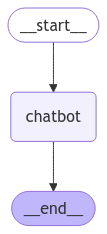

In [13]:
from IPython.display import Image,display 
display(Image(app.get_graph().draw_mermaid_png()))

In [15]:
input = {"messages":["hi, I am Dhanushkumar"]}

In [16]:
app.invoke(input)

{'messages': [HumanMessage(content='hi, I am Dhanushkumar', additional_kwargs={}, response_metadata={}, id='87802466-03e0-472d-bd60-5ad5c9a22c3e'),
  AIMessage(content="Hello Dhanushkumar, it's nice to meet you!\n\nWhat can I do for you today? 😊  \n\n", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 16, 'total_tokens': 44, 'completion_time': 0.050909091, 'prompt_time': 0.002306535, 'queue_time': 0.23265409, 'total_time': 0.053215626}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'stop', 'logprobs': None}, id='run-1fee1fd8-9981-4575-992a-86cccd38d19b-0', usage_metadata={'input_tokens': 16, 'output_tokens': 28, 'total_tokens': 44})]}

In [17]:
for output in app.stream(input):
    for k,v in output.items():
        print(k,v)

chatbot {'messages': [AIMessage(content="Hello Dhanushkumar, it's nice to meet you!\n\nWhat can I do for you today? 😊  \n\n", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 16, 'total_tokens': 44, 'completion_time': 0.050909091, 'prompt_time': 0.001908056, 'queue_time': 0.234852637, 'total_time': 0.052817147}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'stop', 'logprobs': None}, id='run-b52e5112-6a31-403c-b8b4-13058718e0d0-0', usage_metadata={'input_tokens': 16, 'output_tokens': 28, 'total_tokens': 44})]}


In [18]:
@tool 
def search(query:str):
    """this is a custom tool"""
    if "sf" in query.lower() or "san francisco" in query.lower():
        return "San Francisco is a city in California and it's 60 degree and foggy"
    return "It's 90 degree and sunny"

In [19]:
search.invoke("What is the temperature in sf?")

"San Francisco is a city in California and it's 60 degree and foggy"

In [21]:
tools = [search]



In [22]:
tool_node = ToolNode(tools)

In [23]:
llm_with_tool = llm.bind_tools(tools)

In [24]:
def call_model(state : MessagesState):
    messages = state['messages']
    response = llm_with_tool.invoke(messages)
    return {"messages": [response]}


In [26]:
response = call_model({"messages":["hi, I am Dhanushkumar"]})
response

{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_z471', 'function': {'arguments': '{"query":"hi, I am Dhanushkumar"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 86, 'prompt_tokens': 943, 'total_tokens': 1029, 'completion_time': 0.156363636, 'prompt_time': 0.041118213, 'queue_time': 0.23173527, 'total_time': 0.197481849}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-74e86858-c101-474f-99ed-4c7f1ed4af59-0', tool_calls=[{'name': 'search', 'args': {'query': 'hi, I am Dhanushkumar'}, 'id': 'call_z471', 'type': 'tool_call'}], usage_metadata={'input_tokens': 943, 'output_tokens': 86, 'total_tokens': 1029})]}

In [27]:
messages = response['messages']

print(messages)

last_message = messages[-1]

print(last_message)

last_message.tool_calls

[AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_z471', 'function': {'arguments': '{"query":"hi, I am Dhanushkumar"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 86, 'prompt_tokens': 943, 'total_tokens': 1029, 'completion_time': 0.156363636, 'prompt_time': 0.041118213, 'queue_time': 0.23173527, 'total_time': 0.197481849}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-74e86858-c101-474f-99ed-4c7f1ed4af59-0', tool_calls=[{'name': 'search', 'args': {'query': 'hi, I am Dhanushkumar'}, 'id': 'call_z471', 'type': 'tool_call'}], usage_metadata={'input_tokens': 943, 'output_tokens': 86, 'total_tokens': 1029})]
content='' additional_kwargs={'tool_calls': [{'id': 'call_z471', 'function': {'arguments': '{"query":"hi, I am Dhanushkumar"}', 'name': 'search'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 86, 'pro

[{'name': 'search',
  'args': {'query': 'hi, I am Dhanushkumar'},
  'id': 'call_z471',
  'type': 'tool_call'}]

In [28]:
reponse = call_model({"messages":["What is the temperature in India?"]})

In [30]:
response.get("messages")[-1].tool_calls

[{'name': 'search',
  'args': {'query': 'hi, I am Dhanushkumar'},
  'id': 'call_z471',
  'type': 'tool_call'}]

In [31]:
def router_function(state : MessagesState)-> Literal["tools", END]:
    messages = state['messages']
    last_message = messages[-1]

    if last_message.tool_calls:
        return "tools"
    return END


In [32]:
# Define a new graph
workflow = StateGraph(MessagesState)

workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")

workflow.add_conditional_edges("agent",router_function,{"tools": "tools", END: END})

app = workflow.compile()

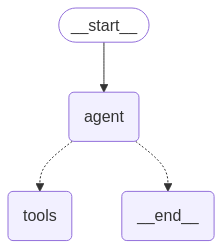

In [33]:
display(Image(app.get_graph().draw_mermaid_png()))

In [34]:
app.invoke({"messages": ["hi how are you?"]})

{'messages': [HumanMessage(content='hi how are you?', additional_kwargs={}, response_metadata={}, id='ebeecc45-2a56-4c31-a942-70e5378f02b8'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_mj4d', 'function': {'arguments': '{"query":"how are you"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 941, 'total_tokens': 1021, 'completion_time': 0.145454545, 'prompt_time': 0.040873082, 'queue_time': 0.23344187300000002, 'total_time': 0.186327627}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-02bf9528-3c4f-43db-b671-5817e5952e9f-0', tool_calls=[{'name': 'search', 'args': {'query': 'how are you'}, 'id': 'call_mj4d', 'type': 'tool_call'}], usage_metadata={'input_tokens': 941, 'output_tokens': 80, 'total_tokens': 1021}),
  ToolMessage(content="It's 90 degree and sunny", name='search', id='1f80b945-291a-41b2-a480-315c4537

In [35]:

workflow.add_edge("tools", 'agent')

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [36]:

app = workflow.compile()

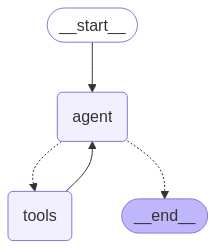

In [37]:
display(Image(app.get_graph().draw_mermaid_png()))

In [38]:
for output in app.stream({"messages": ["what is the weather in sf"]}):
    for key,value in output.items():
        print(f"here is output from {key}")
        print("_______")
        print(value)
        print("\n")

here is output from agent
_______
{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_yznw', 'function': {'arguments': '{"query":"weather in sf"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 82, 'prompt_tokens': 942, 'total_tokens': 1024, 'completion_time': 0.149090909, 'prompt_time': 0.03295444, 'queue_time': 0.23878722300000002, 'total_time': 0.182045349}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-3cb8aff8-844b-4db8-9e53-f8f6630c7dbb-0', tool_calls=[{'name': 'search', 'args': {'query': 'weather in sf'}, 'id': 'call_yznw', 'type': 'tool_call'}], usage_metadata={'input_tokens': 942, 'output_tokens': 82, 'total_tokens': 1024})]}


here is output from tools
_______
{'messages': [ToolMessage(content="San Francisco is a city in California and it's 60 degree and foggy", name='search', id='84c277f2-d45a-49a9-8b5f-0c3b29cab4

In [39]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [40]:
# Define a new graph
workflow3 = StateGraph(MessagesState)

workflow3.add_node("agent", call_model)
workflow3.add_node("tools", tool_node)

workflow3.add_edge(START, "agent")

workflow3.add_conditional_edges("agent",router_function,{"tools": "tools", END: END})

workflow3.add_edge("tools", 'agent')

In [41]:

app3 = workflow3.compile(checkpointer = memory)


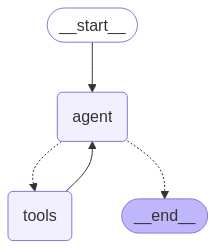

In [42]:
display(Image(app3.get_graph().draw_mermaid_png()))

In [46]:
config = {"configurable": {"thread_id": "1"}}
events = app3.stream(
    {"messages": ["Hi there! My name is Dhanushkumar."]}, config, stream_mode="values"
)

In [47]:
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there! My name is Dhanushkumar.
================================== Ai Message ==================================

Hi Dhanushkumar!


In [48]:
events = app3.stream(
    {"messages": ["can you tell me what was my name?"]}, config, stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

can you tell me what was my name?
================================== Ai Message ==================================

Your name is Dhanushkumar.


In [49]:

memory.get(config)

{'v': 1,
 'ts': '2025-03-14T07:50:55.237133+00:00',
 'id': '1f000a90-f2a0-6884-800c-4ad1504983b4',
 'channel_values': {'messages': [HumanMessage(content='Hi there! My name is Sunny.', additional_kwargs={}, response_metadata={}, id='5794da0c-3cd2-452c-a828-95d27d0ee690'),
   AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_k8mt', 'function': {'arguments': '{"query":"Hello"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 944, 'total_tokens': 1024, 'completion_time': 0.145454545, 'prompt_time': 0.044011675, 'queue_time': 0.236545839, 'total_time': 0.18946622}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-63263f06-fec4-4d09-a3a7-da9b1b198fdf-0', tool_calls=[{'name': 'search', 'args': {'query': 'Hello'}, 'id': 'call_k8mt', 'type': 'tool_call'}], usage_metadata={'input_tokens': 944, 'output_tokens': 80, 'total_tokens':